In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

# Features and target
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize BMI only
scaler = StandardScaler()
X_train[['BMI']] = scaler.fit_transform(X_train[['BMI']])
X_test[['BMI']] = scaler.transform(X_test[['BMI']])

# Train MLP neural network
mlp = MLPClassifier(hidden_layer_sizes=(32,16), activation='relu',
                    solver='adam', max_iter=200, early_stopping=True, random_state=42, verbose=True)

mlp.fit(X_train, y_train)

# Predictions
y_pred = mlp.predict(X_test)


Iteration 1, loss = 0.59995039
Validation score: 0.741513
Iteration 2, loss = 0.52082845
Validation score: 0.744165
Iteration 3, loss = 0.51676569
Validation score: 0.752122
Iteration 4, loss = 0.51456408
Validation score: 0.751591
Iteration 5, loss = 0.51204834
Validation score: 0.754774
Iteration 6, loss = 0.51096326
Validation score: 0.754774
Iteration 7, loss = 0.51058626
Validation score: 0.749646
Iteration 8, loss = 0.50900460
Validation score: 0.751238
Iteration 9, loss = 0.50862017
Validation score: 0.749646
Iteration 10, loss = 0.50766705
Validation score: 0.748586
Iteration 11, loss = 0.50763124
Validation score: 0.757603
Iteration 12, loss = 0.50704843
Validation score: 0.757426
Iteration 13, loss = 0.50679034
Validation score: 0.752829
Iteration 14, loss = 0.50613028
Validation score: 0.754597
Iteration 15, loss = 0.50474085
Validation score: 0.751768
Iteration 16, loss = 0.50508020
Validation score: 0.756188
Iteration 17, loss = 0.50493603
Validation score: 0.754243
Iterat

In [15]:
# Classification metrics table
report_dict = classification_report(
    y_test, y_pred, target_names=["No Diabetes", "Diabetes"], output_dict=True
)
metrics_df = pd.DataFrame(report_dict).transpose()
metrics_df = metrics_df[['precision', 'recall', 'f1-score', 'support']]
metrics_df = metrics_df.round(2)
metrics_df.index = ["No Diabetes", "Diabetes", "Accuracy", "Macro Avg", "Weighted Avg"]


print("\nClassification Metrics Table:\n")
display(metrics_df.style.set_caption("MLP Classification Metrics").set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center')]},
     {'selector': 'td', 'props': [('text-align', 'center')]}]
))



Classification Metrics Table:



,precision,recall,f1-score,support
No Diabetes,0.770000,0.710000,0.740000,7070.000000
Diabetes,0.730000,0.790000,0.760000,7069.000000
Accuracy,0.750000,0.750000,0.750000,0.750000
Macro Avg,0.750000,0.750000,0.750000,14139.000000
Weighted Avg,0.750000,0.750000,0.750000,14139.000000


Confusion Matrix:
 [[5042 2028]
 [1485 5584]]


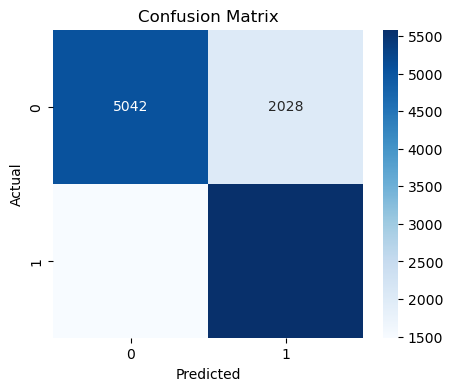

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Confusion matrix graph
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

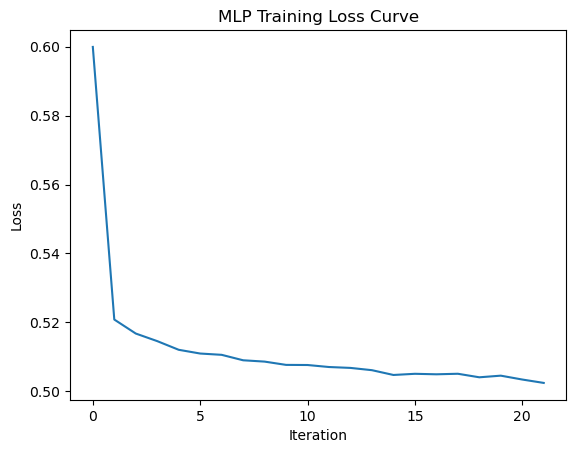

In [14]:
# Plot training loss curve
plt.plot(mlp.loss_curve_)
plt.title('MLP Training Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()